In [1]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('sty.mplstyle')

from models.couplings import *

from models.nobile import NobileF1
from models.anand import AnandF1
from models.nobile import NobileF6
from models.anand import AnandF6

from detectors.scdms import SiHV
from detectors.ge_theo import Ge

from veldists import VelDist
from constants import *


In [16]:
Det = Ge(0,"Fitz")
Dist = VelDist("avSHM",0.3)

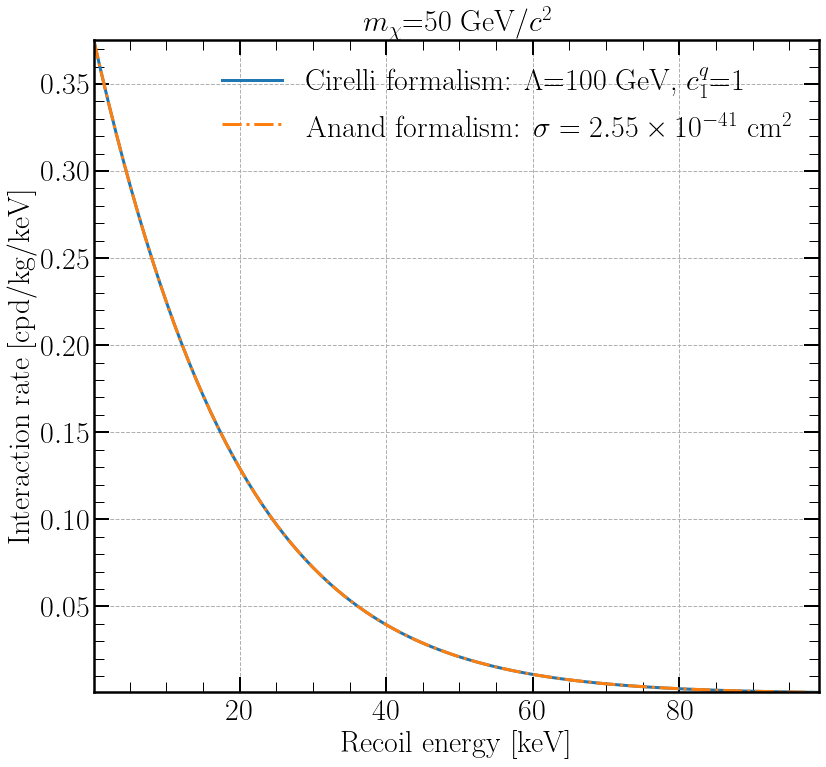

In [23]:
## Lets do F1 first
mX = 50*GeV
Lam = 100*GeV
c1 = c1_NR(c_q,mX,Lam)
cn_NR = c1[1] # NR EFT coupling assuming EFT cn = 0.433/pow(lam*keV,3)
cp_NR = c1[0] # NR EFT coupling assuming EFT cp = 0.3754/pow(lam*keV,3)
c2 = (cn_NR**2 + cp_NR**2)/((4*mX*mp)**2) # conversion for the Anand model
sig = eV2_to_cm2*pow(mp*mX/(mp+mX),2)*c2/np.pi

F1A = AnandF1(cp_NR,cn_NR)
F1C = NobileF1(cp_NR,cn_NR)

E = np.arange(0.1,100,1) # observed energy, units of keV_ee
plt.plot(E,[Det.dRdE_True(e,F1C.dRdER,mX=50*GeV,VelDist=Dist) for e in E])
plt.plot(E,[Det.dRdE_True(e,F1A.dRdER,mX=50*GeV,sig=sig,VelDist=Dist) for e in E],"-.")
plt.xlabel("Recoil energy [keV]")
plt.ylabel("Interaction rate [cpd/kg/keV]")
plt.title(r"$m_{\chi}$=50 GeV/$c^2$")
plt.legend([r"Cirelli formalism: $\Lambda$=100 GeV, $c_1^q$=1",r"Anand formalism: $\sigma=2.55\times 10^{-41}$ cm$^2$"])
plt.grid()
plt.show()

In [8]:
## Now lets try F6
## This quark coupling is a bit more complex.



mBar = (1/m("u") + 1/m("d") + 1/m("s"))**(-1)     

def cq4(q,Lambda):
    return m(q)/(Lambda**3)

def C4(Lambda):
    return sum(cq4(q,Lambda)*mBar/m(q) for q in ["u","d","s","t","b","c"] )


def Rc4(N,Lambda):
    return sum( (mp/m(q))*CDelta(N,q)*((cq4(q,Lambda)-C4(Lambda)))  for q in ["u","d","s"] )

def c6(N,mchi,Lambda):
    return 4*Rc4(N, Lambda)

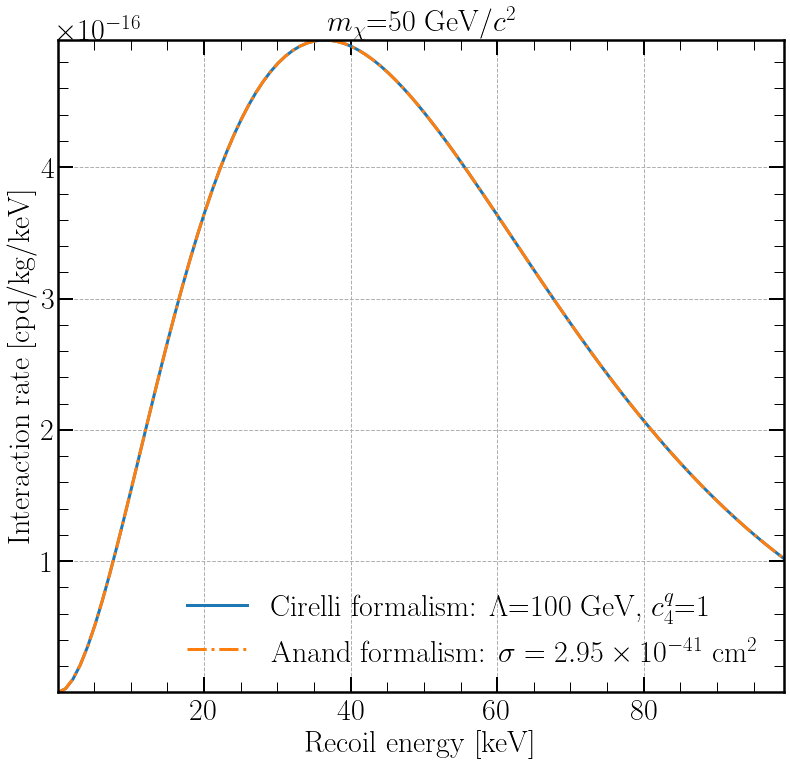

In [12]:
cp_cir = c6("p",mX,Lam)
cn_cir = c6("n",mX,Lam)

# get the units appropriate for sigma calc
cp_an = Rc4("p",Lam)*mp/mX
cn_an = Rc4("n",Lam)*mp/mX
c2 = cp_an*cp_an + cn_an*cn_an # coupling constants squared sum
sig = eV2_to_cm2*pow(mp*mX/(mp+mX),2)*c2/np.pi

F6A = AnandF6(cp_cir,cn_cir,1)
F6C = NobileF6(cp_cir,cn_cir,1)

E = np.arange(0.1,100,1) # observed energy, units of keV_ee
plt.plot(E,[Det.dRdE_True(e,F6C.dRdER,mX=50*GeV,VelDist=Dist) for e in E])
plt.plot(E,[Det.dRdE_True(e,F6A.dRdER,mX=50*GeV,sig=sig,VelDist=Dist) for e in E],"-.")
plt.xlabel("Recoil energy [keV]")
plt.ylabel("Interaction rate [cpd/kg/keV]")
plt.title(r"$m_{\chi}$=50 GeV/$c^2$")
plt.legend([r"Cirelli formalism: $\Lambda$=100 GeV, $c_4^q$=1",r"Anand formalism: $\sigma=2.95\times 10^{-41}$ cm$^2$"])
plt.grid()
plt.show()

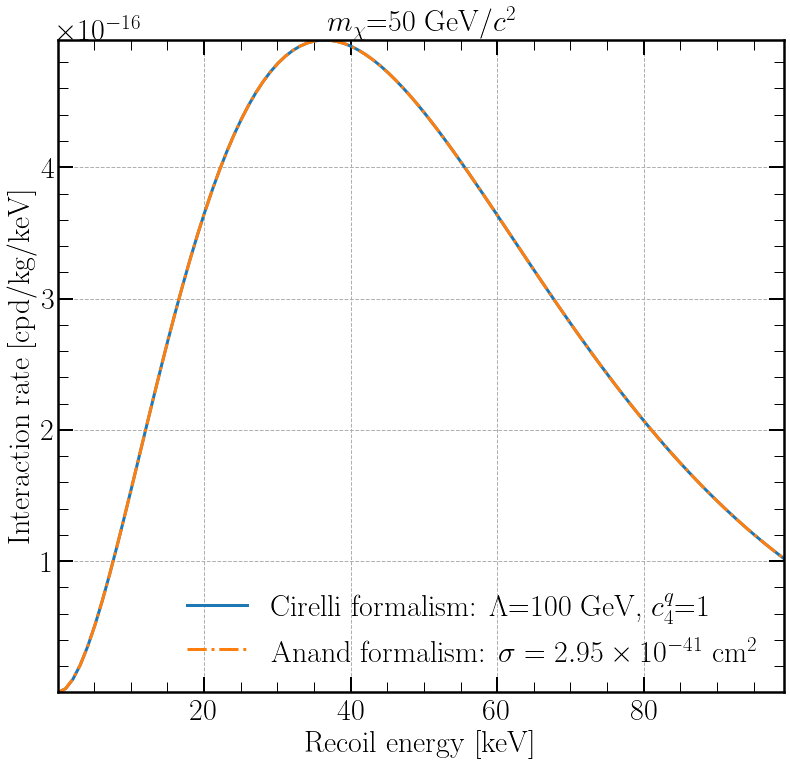

In [27]:
cp_cir = c6_NR(c_q,Lam)[0]
cn_cir = c6_NR(c_q,Lam)[1]

# get the units appropriate for sigma calc
cp_an = 0.25*cp_cir*mp/mX
cn_an = 0.25*cn_cir*mp/mX
c2 = cp_an*cp_an + cn_an*cn_an # coupling constants squared sum
sig = eV2_to_cm2*pow(mp*mX/(mp+mX),2)*c2/np.pi

F6A = AnandF6(cp_cir,cn_cir,1)
F6C = NobileF6(cp_cir,cn_cir,1)

E = np.arange(0.1,100,1) # observed energy, units of keV_ee
plt.plot(E,[Det.dRdE_True(e,F6C.dRdER,mX=50*GeV,VelDist=Dist) for e in E])
plt.plot(E,[Det.dRdE_True(e,F6A.dRdER,mX=50*GeV,sig=sig,VelDist=Dist) for e in E],"-.")
plt.xlabel("Recoil energy [keV]")
plt.ylabel("Interaction rate [cpd/kg/keV]")
plt.title(r"$m_{\chi}$=50 GeV/$c^2$")
plt.legend([r"Cirelli formalism: $\Lambda$=100 GeV, $c_4^q$=1",r"Anand formalism: $\sigma=2.95\times 10^{-41}$ cm$^2$"])
plt.grid()
plt.show()

In [24]:
c_q = {
    "c1":0,
    "c2":0,
    "c3":0,
    "c4":1,
    "c5":0,
    "c6":0,
    "c7":0,
    "c8":0,
    "c9":0,
    "c10":0,
}

In [13]:
c1_NR(c_q,50*GeV,1E9)

[624.0496815980738, 624.45459951863]

In [28]:
sig

1.352423519540666e-43

In [44]:
Delta["p"]["c"]

0